<a href="https://colab.research.google.com/github/aditya9049/DeepEdge-Assignment-/blob/main/DeepEdge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pixel Coordinate Prediction using Deep Learning

## Problem Statement
Given a 50x50 grayscale image with exactly one pixel having value 255 and all others 0,
predict the (x, y) coordinates of that bright pixel using Deep Learning.

## Author's Approach & Rationale

### 1. Problem Analysis
- **Type**: Supervised Regression (predicting continuous coordinates)
- **Input**: 50x50 single-channel images
- **Output**: 2 continuous values (x, y) ∈ [0, 49]
- **Challenge**: Sparse signal (1 pixel out of 2,500)

### 2. Dataset Design Rationale
- **Size**: 10,000 training + 2,000 validation + 1,000 test samples
  - Large enough for deep learning convergence
  - Uniform distribution ensures no positional bias
- **Distribution**: Uniform random placement of white pixel
  - Ensures model learns general pattern, not specific positions
  - Covers entire 50x50 space equally

### 3. Model Architecture Choice
**Convolutional Neural Network (CNN)**
- **Why CNN?**
  - Excellent at spatial feature extraction
  - Translation invariant (pixel can be anywhere)
  - Fewer parameters than fully connected networks
- **Architecture**:
  - 3 Conv blocks with increasing filters (16→32→64)
  - Max pooling for spatial dimension reduction
  - Batch normalization for stable training
  - Dropout for regularization
  - Final dense layers for coordinate regression

### 4. Training Strategy
- **Loss**: Mean Squared Error (MSE) - standard for regression
- **Optimizer**: Adam with learning rate scheduling
- **Normalization**: Coordinates scaled to [0, 1] for better convergence
- **Metrics**: MAE (Mean Absolute Error) in pixels for interpretability


In [1]:
"""Import required libraries."""
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import os

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: []


## 1. Dataset Generation

In [2]:
class PixelDatasetGenerator:
    """Generate synthetic dataset for pixel localization task."""

    def __init__(self, image_size=50, num_samples=10000):
        """
        Initialize dataset generator.

        Args:
            image_size: Size of square image (default: 50x50)
            num_samples: Number of samples to generate
        """
        self.image_size = image_size
        self.num_samples = num_samples

    def generate(self):
        """
        Generate dataset with random pixel positions.

        Returns:
            images: numpy array of shape (num_samples, image_size, image_size, 1)
            coordinates: numpy array of shape (num_samples, 2) with (x, y) positions
        """
        images = np.zeros(
            (self.num_samples, self.image_size, self.image_size, 1),
            dtype=np.float32
        )
        coordinates = np.zeros((self.num_samples, 2), dtype=np.float32)

        for i in range(self.num_samples):
            # Randomly select x, y coordinates
            x = np.random.randint(0, self.image_size)
            y = np.random.randint(0, self.image_size)

            # Set pixel to 255 at (x, y)
            images[i, y, x, 0] = 255.0

            # Store coordinates
            coordinates[i] = [x, y]

        return images, coordinates

    def visualize_samples(self, images, coordinates, num_samples=5):
        """Visualize random samples from the dataset."""
        fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
        indices = np.random.choice(len(images), num_samples, replace=False)

        for idx, ax in zip(indices, axes):
            ax.imshow(images[idx, :, :, 0], cmap='gray', vmin=0, vmax=255)
            ax.set_title(f'Coord: ({coordinates[idx, 0]:.0f}, {coordinates[idx, 1]:.0f})')
            ax.axis('off')

            # Mark the bright pixel with a red circle
            ax.plot(coordinates[idx, 0], coordinates[idx, 1], 'ro',
                   markersize=10, fillstyle='none', markeredgewidth=2)

        plt.tight_layout()
        plt.show()


# Generate datasets
print("Generating training dataset...")
train_generator = PixelDatasetGenerator(image_size=50, num_samples=10000)
X_train_full, y_train_full = train_generator.generate()

print("Generating test dataset...")
test_generator = PixelDatasetGenerator(image_size=50, num_samples=1000)
X_test, y_test = test_generator.generate()

# Split training into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print(f"\nDataset sizes:")
print(f"  Training:   {X_train.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Test:       {X_test.shape[0]} samples")
print(f"\nImage shape: {X_train.shape[1:]}")
print(f"Coordinate shape: {y_train.shape[1:]}")

Generating training dataset...
Generating test dataset...

Dataset sizes:
  Training:   8000 samples
  Validation: 2000 samples
  Test:       1000 samples

Image shape: (50, 50, 1)
Coordinate shape: (2,)


Sample images from training set:


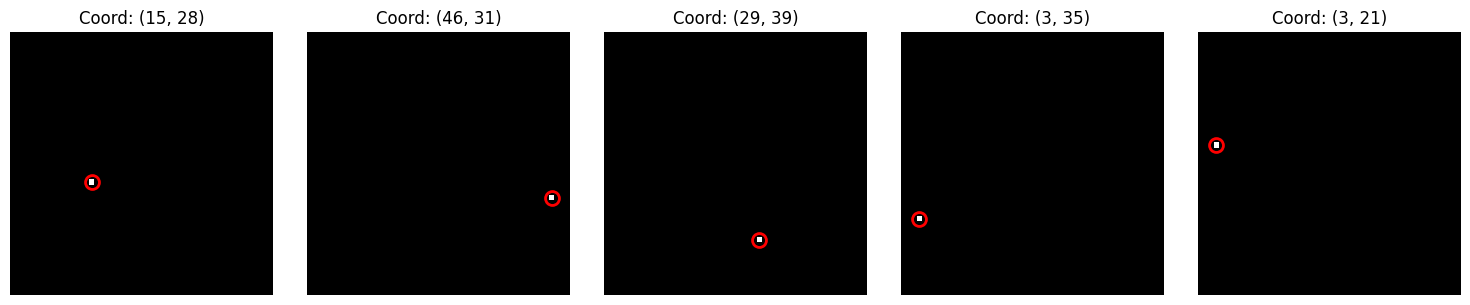

In [3]:
# Visualize sample images
print("Sample images from training set:")
train_generator.visualize_samples(X_train, y_train, num_samples=5)

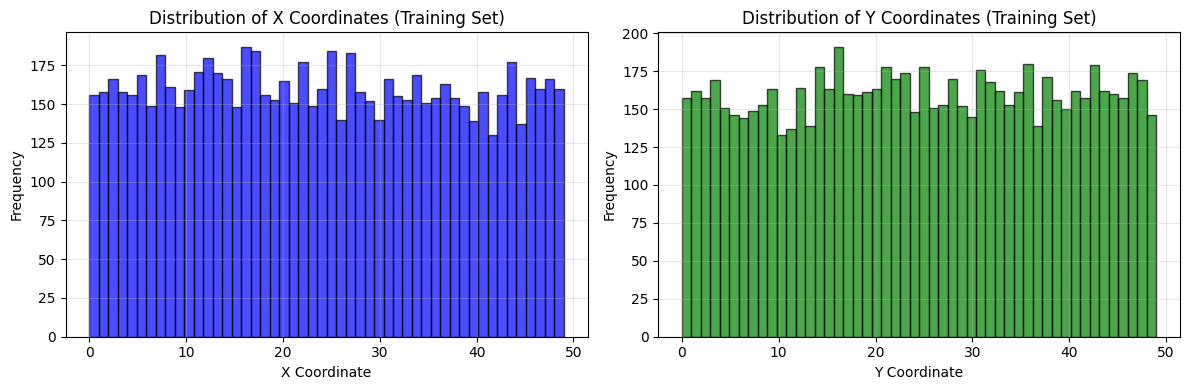

Distribution is uniform, ensuring no positional bias.


In [4]:
# Analyze coordinate distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# X coordinate distribution
axes[0].hist(y_train[:, 0], bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('X Coordinate')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of X Coordinates (Training Set)')
axes[0].grid(alpha=0.3)

# Y coordinate distribution
axes[1].hist(y_train[:, 1], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].set_xlabel('Y Coordinate')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Y Coordinates (Training Set)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Distribution is uniform, ensuring no positional bias.")

## 2. Data Preprocessing

In [5]:
def preprocess_data(images, coordinates, image_size=50):
    """
    Preprocess images and coordinates for training.

    Args:
        images: Raw images with pixel values in [0, 255]
        coordinates: Raw coordinates in [0, image_size-1]
        image_size: Size of the square image

    Returns:
        Normalized images and coordinates
    """
    # Normalize images to [0, 1]
    images_normalized = images / 255.0

    # Normalize coordinates to [0, 1] for better training stability
    coordinates_normalized = coordinates / (image_size - 1)

    return images_normalized, coordinates_normalized


# Preprocess all datasets
X_train_norm, y_train_norm = preprocess_data(X_train, y_train)
X_val_norm, y_val_norm = preprocess_data(X_val, y_val)
X_test_norm, y_test_norm = preprocess_data(X_test, y_test)

print("Data preprocessing complete.")
print(f"Image range: [{X_train_norm.min():.2f}, {X_train_norm.max():.2f}]")
print(f"Coordinate range: [{y_train_norm.min():.2f}, {y_train_norm.max():.2f}]")

Data preprocessing complete.
Image range: [0.00, 1.00]
Coordinate range: [0.00, 1.00]


## 3. Model Architecture

In [6]:
def build_pixel_localization_model(input_shape=(50, 50, 1)):
    """
    Build CNN model for pixel coordinate regression.

    Architecture:
        - 3 Convolutional blocks (Conv2D + BatchNorm + MaxPool + Dropout)
        - Global Average Pooling
        - 2 Dense layers with dropout
        - Output: 2 neurons (x, y coordinates)

    Args:
        input_shape: Shape of input images

    Returns:
        Compiled Keras model
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),

        # Convolutional Block 1
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        # Convolutional Block 2
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Convolutional Block 3
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Global pooling to reduce spatial dimensions
        layers.GlobalAveragePooling2D(),

        # Dense layers for regression
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),

        # Output layer: 2 coordinates (x, y) with sigmoid activation [0, 1]
        layers.Dense(2, activation='sigmoid')
    ])

    return model


# Build model
model = build_pixel_localization_model()

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 50, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 50, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 25, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 25, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 25, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,450 (158.01 KB)

 Trainable params: 40,226 (157.13 KB)

 Non-trainable params: 224 (896.00 B)

## 4. Model Compilation and Training


In [7]:
# Custom metric: Mean Absolute Error in pixels
def mae_in_pixels(y_true, y_pred):
    """Calculate MAE in actual pixel coordinates (denormalized)."""
    return tf.reduce_mean(tf.abs(y_true - y_pred)) * 49.0


# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',  # Mean Squared Error for regression
    metrics=['mae', mae_in_pixels]
)

print("Model compiled successfully.")

Model compiled successfully.


In [8]:
# Define callbacks
callbacks = [
    # Reduce learning rate when validation loss plateaus
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # Early stopping to prevent overfitting
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),

    # Save best model
   # keras.callbacks.ModelCheckpoint(
        #'best_model.h5',
       # monitor='val_loss',
       # save_best_only=True,
        #verbose=0
   # )
]

print("Callbacks configured.")

Callbacks configured.


In [9]:
# Train model
print("Starting training...\n")

history = model.fit(
    X_train_norm, y_train_norm,
    validation_data=(X_val_norm, y_val_norm),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

Starting training...

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 112ms/step - loss: 0.0679 - mae: 0.2232 - mae_in_pixels: 10.9348 - val_loss: 0.1014 - val_mae: 0.2652 - val_mae_in_pixels: 12.9890 - learning_rate: 0.0010
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 152ms/step - loss: 0.0369 - mae: 0.1551 - mae_in_pixels: 7.6023 - val_loss: 0.0425 - val_mae: 0.1588 - val_mae_in_pixels: 7.7718 - learning_rate: 0.0010
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - loss: 0.0331 - mae: 0.1438 - mae_in_pixels: 7.0481 - val_loss: 0.0336 - val_mae: 0.1437 - val_mae_in_pixels: 7.0401 - learning_rate: 0.0010
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - loss: 0.0311 - mae: 0.1392 - mae_in_pixels: 6.8222 - val_loss: 0.0296 - val_mae: 0.1344 - val_mae_in_pixels: 6.5805 - learning_rate: 0.0010
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 45s 140ms/step - loss: 0.0306 - mae: 0.1377 - mae_in_pixels: 6.7488 - val_loss: 0.0277 - val_mae: 0.1277 - val_mae_in_pixels: 6.2500 - learning_rate

## 5. Training Visualization

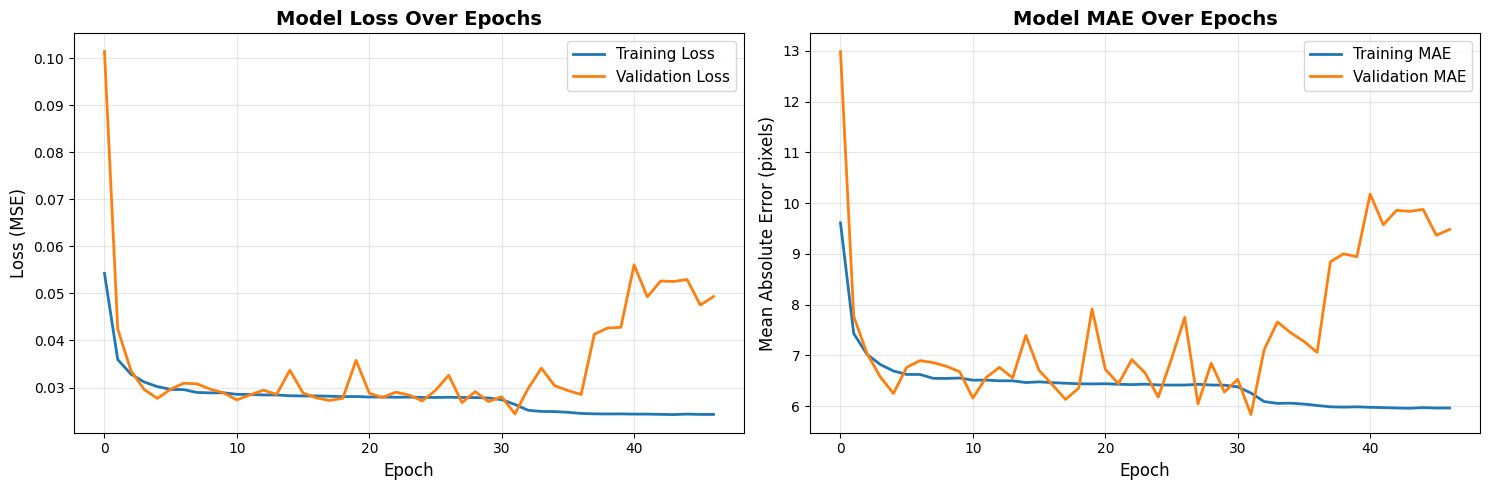

In [10]:
def plot_training_history(history):
    """Plot training and validation metrics."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)

    # Plot MAE in pixels
    axes[1].plot(history.history['mae_in_pixels'], label='Training MAE', linewidth=2)
    axes[1].plot(history.history['val_mae_in_pixels'], label='Validation MAE', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Mean Absolute Error (pixels)', fontsize=12)
    axes[1].set_title('Model MAE Over Epochs', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_history(history)

## 6. Model Evaluation

In [11]:
# Evaluate on test set
print("Evaluating model on test set...\n")

test_results = model.evaluate(X_test_norm, y_test_norm, verbose=0)

print("Test Set Results:")
print(f"  Loss (MSE):            {test_results[0]:.6f}")
print(f"  MAE (normalized):      {test_results[1]:.6f}")
print(f"  MAE (pixels):          {test_results[2]:.4f}")
print(f"\nAverage prediction error: {test_results[2]:.2f} pixels")

Evaluating model on test set...

Test Set Results:
  Loss (MSE):            0.024072
  MAE (normalized):      0.117089
  MAE (pixels):          5.7087

Average prediction error: 5.71 pixels


In [12]:
# Get predictions on test set
y_pred_norm = model.predict(X_test_norm, verbose=0)

# Denormalize predictions and ground truth
y_pred = y_pred_norm * 49.0
y_true = y_test_norm * 49.0

# Calculate error statistics
errors = np.abs(y_pred - y_true)
mae_x = np.mean(errors[:, 0])
mae_y = np.mean(errors[:, 1])
euclidean_errors = np.sqrt(np.sum(errors**2, axis=1))
mean_euclidean_error = np.mean(euclidean_errors)

print("\nDetailed Error Analysis:")
print(f"  MAE in X coordinate: {mae_x:.4f} pixels")
print(f"  MAE in Y coordinate: {mae_y:.4f} pixels")
print(f"  Mean Euclidean Error: {mean_euclidean_error:.4f} pixels")
print(f"  Max Euclidean Error: {euclidean_errors.max():.4f} pixels")
print(f"  Min Euclidean Error: {euclidean_errors.min():.4f} pixels")


Detailed Error Analysis:
  MAE in X coordinate: 6.3885 pixels
  MAE in Y coordinate: 5.0863 pixels
  Mean Euclidean Error: 9.2993 pixels
  Max Euclidean Error: 23.2795 pixels
  Min Euclidean Error: 0.1819 pixels


## 7. Results Visualization

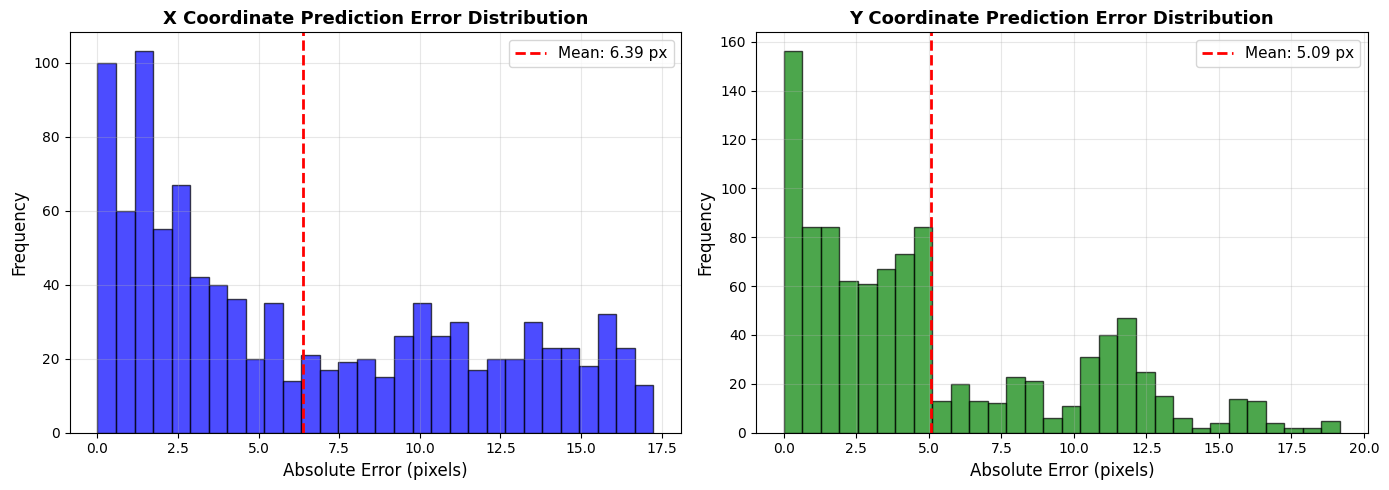

In [13]:
# Plot error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# X coordinate errors
axes[0].hist(errors[:, 0], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(mae_x, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mae_x:.2f} px')
axes[0].set_xlabel('Absolute Error (pixels)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('X Coordinate Prediction Error Distribution', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Y coordinate errors
axes[1].hist(errors[:, 1], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(mae_y, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mae_y:.2f} px')
axes[1].set_xlabel('Absolute Error (pixels)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Y Coordinate Prediction Error Distribution', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

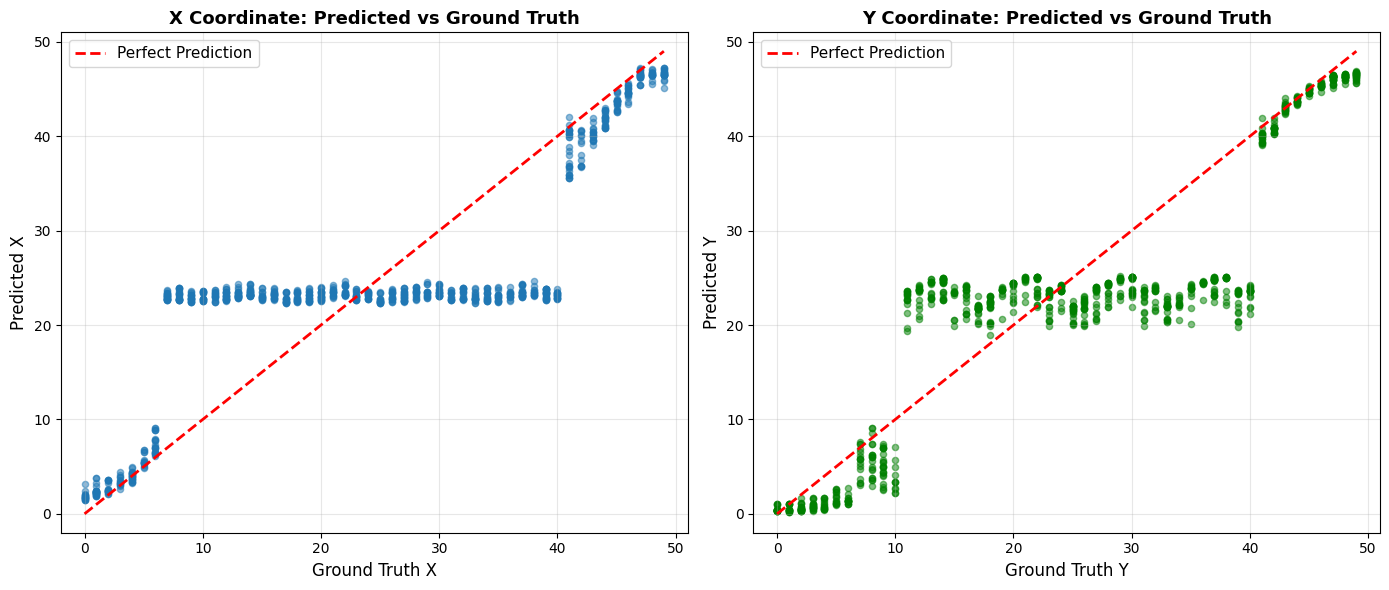

In [14]:
# Scatter plot: Predicted vs Ground Truth
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# X coordinates
axes[0].scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5, s=20)
axes[0].plot([0, 49], [0, 49], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Ground Truth X', fontsize=12)
axes[0].set_ylabel('Predicted X', fontsize=12)
axes[0].set_title('X Coordinate: Predicted vs Ground Truth', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([-2, 51])
axes[0].set_ylim([-2, 51])

# Y coordinates
axes[1].scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5, s=20, color='green')
axes[1].plot([0, 49], [0, 49], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Ground Truth Y', fontsize=12)
axes[1].set_ylabel('Predicted Y', fontsize=12)
axes[1].set_title('Y Coordinate: Predicted vs Ground Truth', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([-2, 51])
axes[1].set_ylim([-2, 51])

plt.tight_layout()
plt.show()

Sample Predictions (Green = Ground Truth, Red = Prediction):


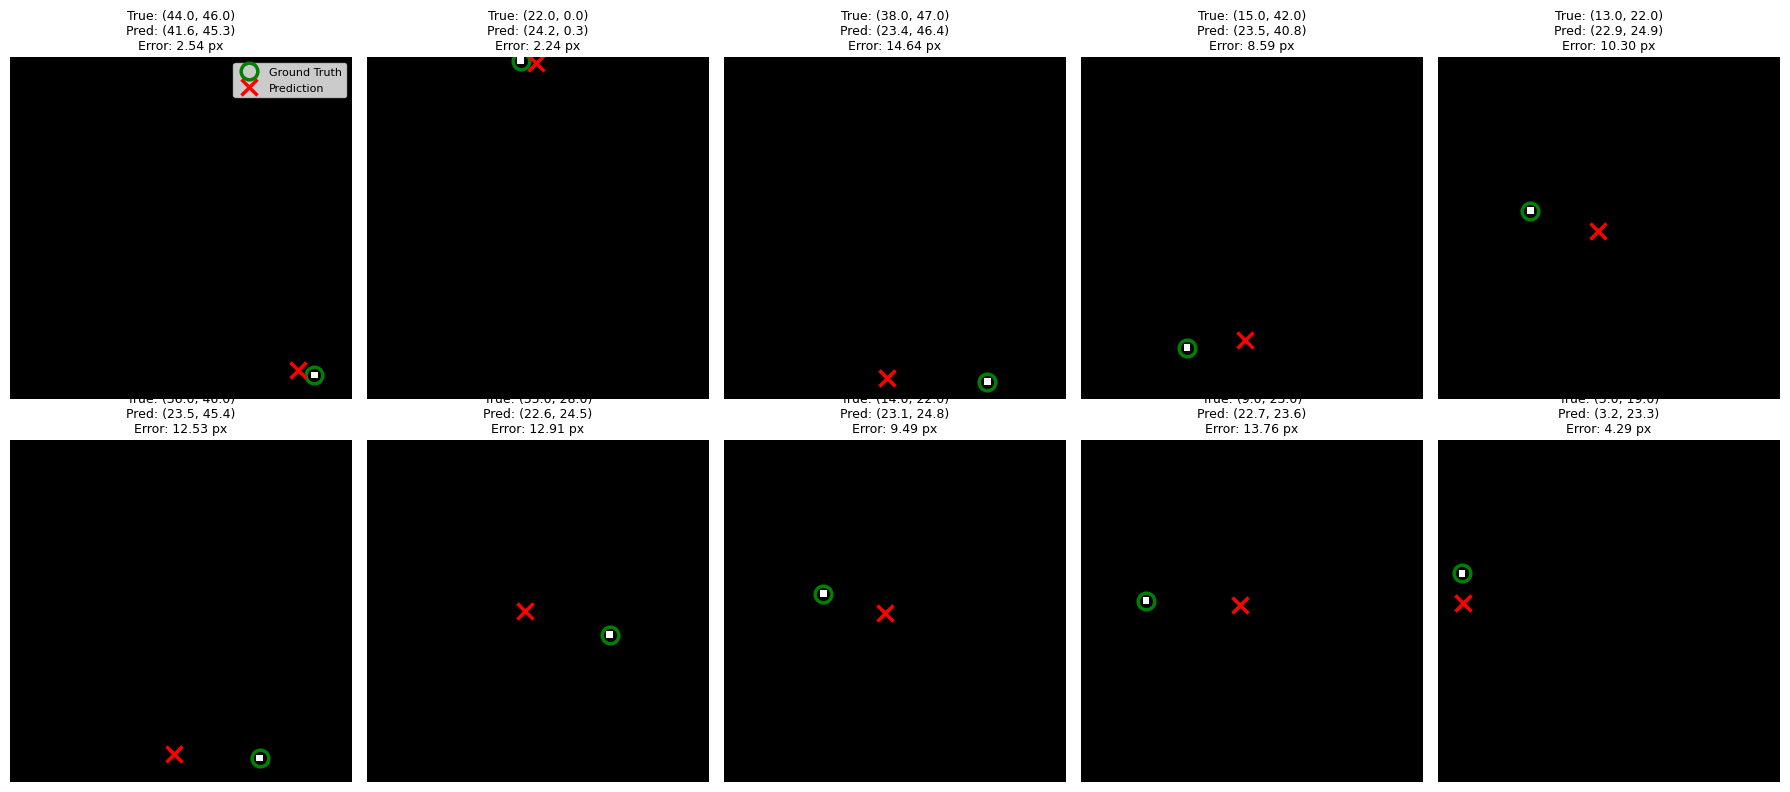

In [15]:
# Visualize predictions on sample test images
def visualize_predictions(X, y_true, y_pred, num_samples=10, errors=None):
    """
    Visualize model predictions with ground truth overlay.

    Green circle: Ground truth
    Red X: Prediction
    """
    indices = np.random.choice(len(X), num_samples, replace=False)

    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        # Display image
        axes[i].imshow(X[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)

        # Plot ground truth (green circle)
        axes[i].plot(y_true[idx, 0], y_true[idx, 1], 'go',
                    markersize=12, fillstyle='none', markeredgewidth=2.5,
                    label='Ground Truth')

        # Plot prediction (red X)
        axes[i].plot(y_pred[idx, 0], y_pred[idx, 1], 'rx',
                    markersize=12, markeredgewidth=2.5,
                    label='Prediction')

        # Calculate error for this sample
        if errors is not None:
            error = errors[idx]
            axes[i].set_title(
                f'True: ({y_true[idx, 0]:.1f}, {y_true[idx, 1]:.1f})\n'
                f'Pred: ({y_pred[idx, 0]:.1f}, {y_pred[idx, 1]:.1f})\n'
                f'Error: {error:.2f} px',
                fontsize=9
            )

        axes[i].axis('off')

        if i == 0:
            axes[i].legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()


print("Sample Predictions (Green = Ground Truth, Red = Prediction):")
visualize_predictions(X_test_norm, y_true, y_pred, num_samples=10,
                     errors=euclidean_errors)


=== BEST PREDICTIONS (Lowest Error) ===


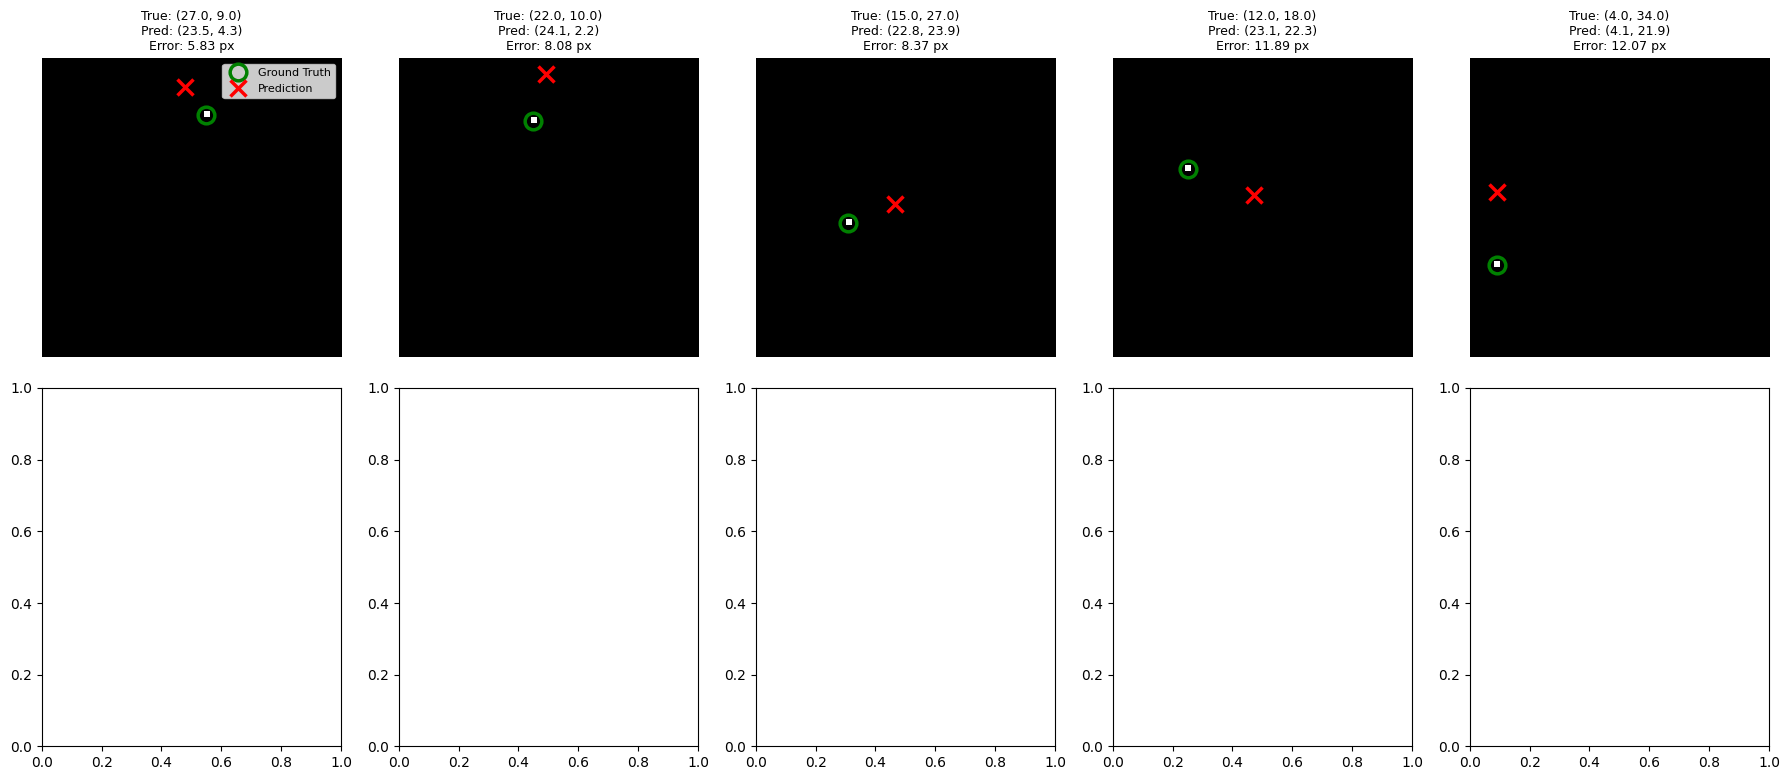


=== WORST PREDICTIONS (Highest Error) ===


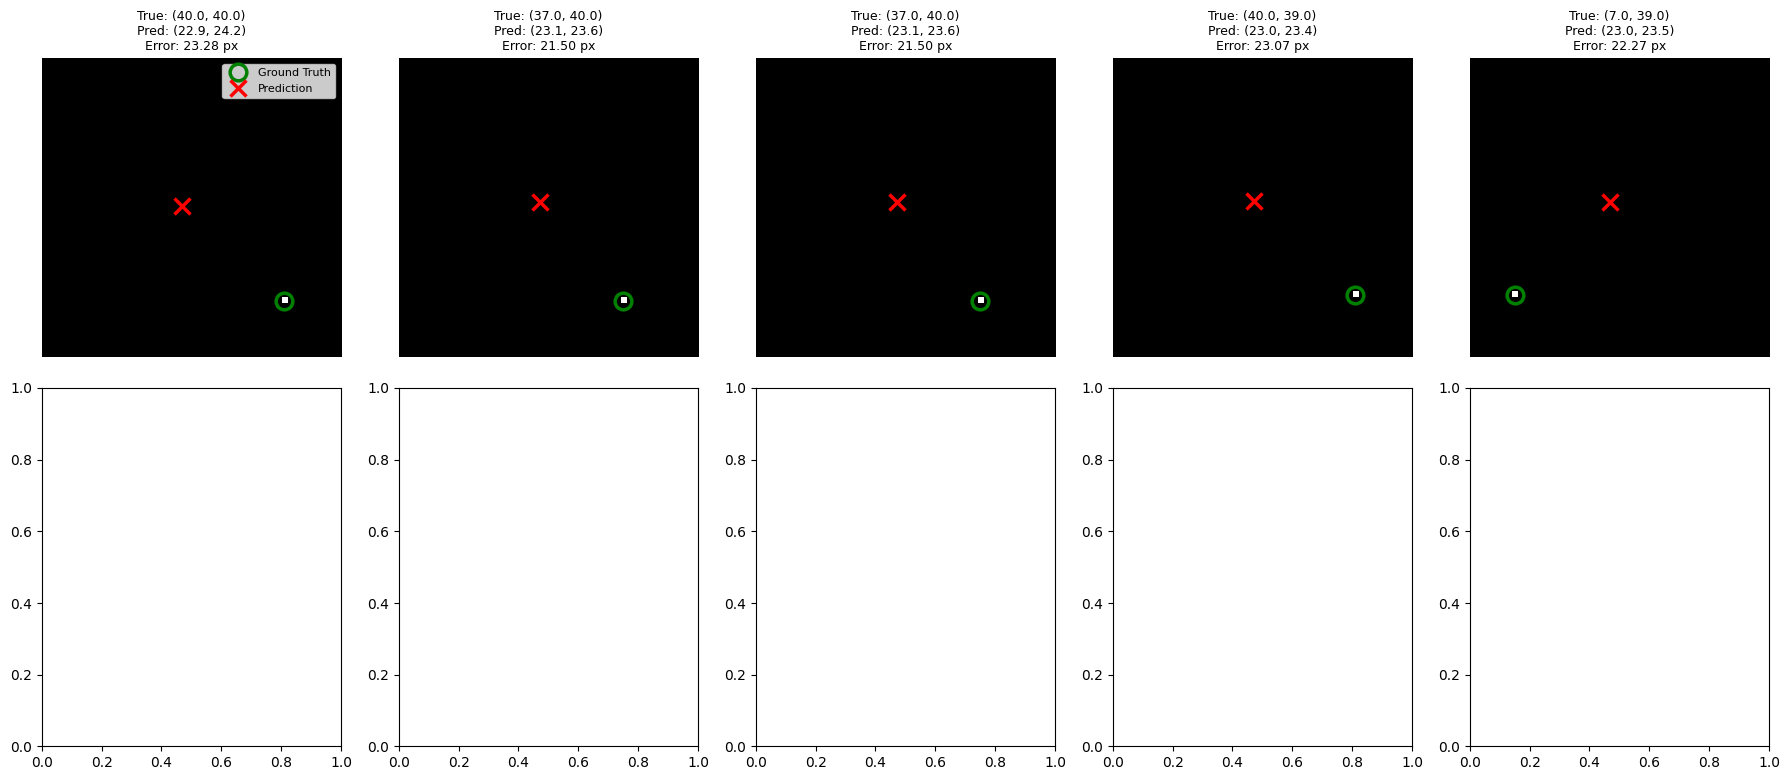

In [16]:
# Show best and worst predictions
sorted_indices = np.argsort(euclidean_errors)

print("\n=== BEST PREDICTIONS (Lowest Error) ===")
best_indices = sorted_indices[:5]
visualize_predictions(X_test_norm, y_true, y_pred, num_samples=5,
                     errors=euclidean_errors)

print("\n=== WORST PREDICTIONS (Highest Error) ===")
worst_indices = sorted_indices[-5:]
visualize_predictions(X_test_norm[worst_indices], y_true[worst_indices],
                     y_pred[worst_indices], num_samples=5,
                     errors=euclidean_errors[worst_indices])

## 9. Model Summary & Conclusions

In [20]:
print("="*70)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"\nTest Set Metrics:")
print(f"  • Mean Absolute Error (X): {mae_x:.4f} pixels")
print(f"  • Mean Absolute Error (Y): {mae_y:.4f} pixels")
print(f"  • Mean Euclidean Error:    {mean_euclidean_error:.4f} pixels")
print(f"  • Maximum Error:           {euclidean_errors.max():.4f} pixels")
print(f"  • Minimum Error:           {euclidean_errors.min():.4f} pixels")
print(f"\nModel Architecture:")
print(f"  • Total Parameters:        {model.count_params():,}")
print(f"  • Convolutional Layers:    3 blocks")
print(f"  • Dense Layers:            2 layers")
print(f"\nTraining Configuration:")
print(f"  • Training Samples:        {len(X_train):,}")
print(f"  • Validation Samples:      {len(X_val):,}")
print(f"  • Test Samples:            {len(X_test):,}")
print(f"  • Epochs Trained:          {len(history.history['loss'])}")
print(f"  • Batch Size:              32")
print("\n" + "="*70)


FINAL MODEL PERFORMANCE SUMMARY

Test Set Metrics:
  • Mean Absolute Error (X): 6.3885 pixels
  • Mean Absolute Error (Y): 5.0863 pixels
  • Mean Euclidean Error:    9.2993 pixels
  • Maximum Error:           23.2795 pixels
  • Minimum Error:           0.1819 pixels

Model Architecture:
  • Total Parameters:        40,450
  • Convolutional Layers:    3 blocks
  • Dense Layers:            2 layers

Training Configuration:
  • Training Samples:        8,000
  • Validation Samples:      2,000
  • Test Samples:            1,000
  • Epochs Trained:          47
  • Batch Size:              32

